# Linear Predictive Coding (LPC)

LPC models the **spectral envelope** of a signal as an all-pole filter of order p:

`H(z) = 1 / (1 − a₁z⁻¹ − a₂z⁻² − … − aₚz⁻ᵖ)`

The coefficients {aₖ} are found by minimising the mean-square prediction error (current sample predicted from the past p samples) via the autocorrelation method and Levinson-Durbin recursion. The poles of H(z) cluster at formant frequencies, providing a compact parametric representation of the vocal tract shape.

| Function | Description |
| --- | --- |
| `lpc_coeffs` | Estimate LPC coefficients from a signal frame using the autocorrelation method. Returns `(a, gain)` where `a` are the predictor coefficients and `gain` is the residual power. |
| `lpc_synthesize` | Apply the all-pole LPC synthesis filter `H(z)` to an excitation signal. Voiced speech uses a pulse train (pitch period); unvoiced speech uses white noise. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_impulse, generate_sine, generate_white_noise
from python.source_filter import lpc_coeffs, lpc_synthesize

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

LPC analysis and synthesis at telephone bandwidth (8 kHz sample rate), order = 12.

**Left panel — spectral envelope:**
- Periodogram of the original signal (grey) vs the smooth LPC spectral envelope `20 log₁₀|H(f)| + 20 log₁₀(gain)` (coloured)
- Peaks in the LPC envelope correspond to formant frequencies; the envelope is guaranteed to be smooth (all-pole with p poles = p/2 formants max)
- The harmonic comb of the pulse excitation is visible beneath the envelope; LPC separates the *source* (harmonic comb) from the *filter* (vocal tract envelope)

**Right panel — LPC resynthesis:**
- Original signal vs the signal reconstructed by passing the known excitation through `lpc_synthesize`
- Good match confirms the LPC model captures the salient spectral shape at this order
- Residual (original − resynthesised) shows what the all-pole model misses — primarily fine spectral detail beyond order p

LPC order 12 is the standard for telephone-bandwidth (8 kHz) speech coding (e.g., GSM, G.728).


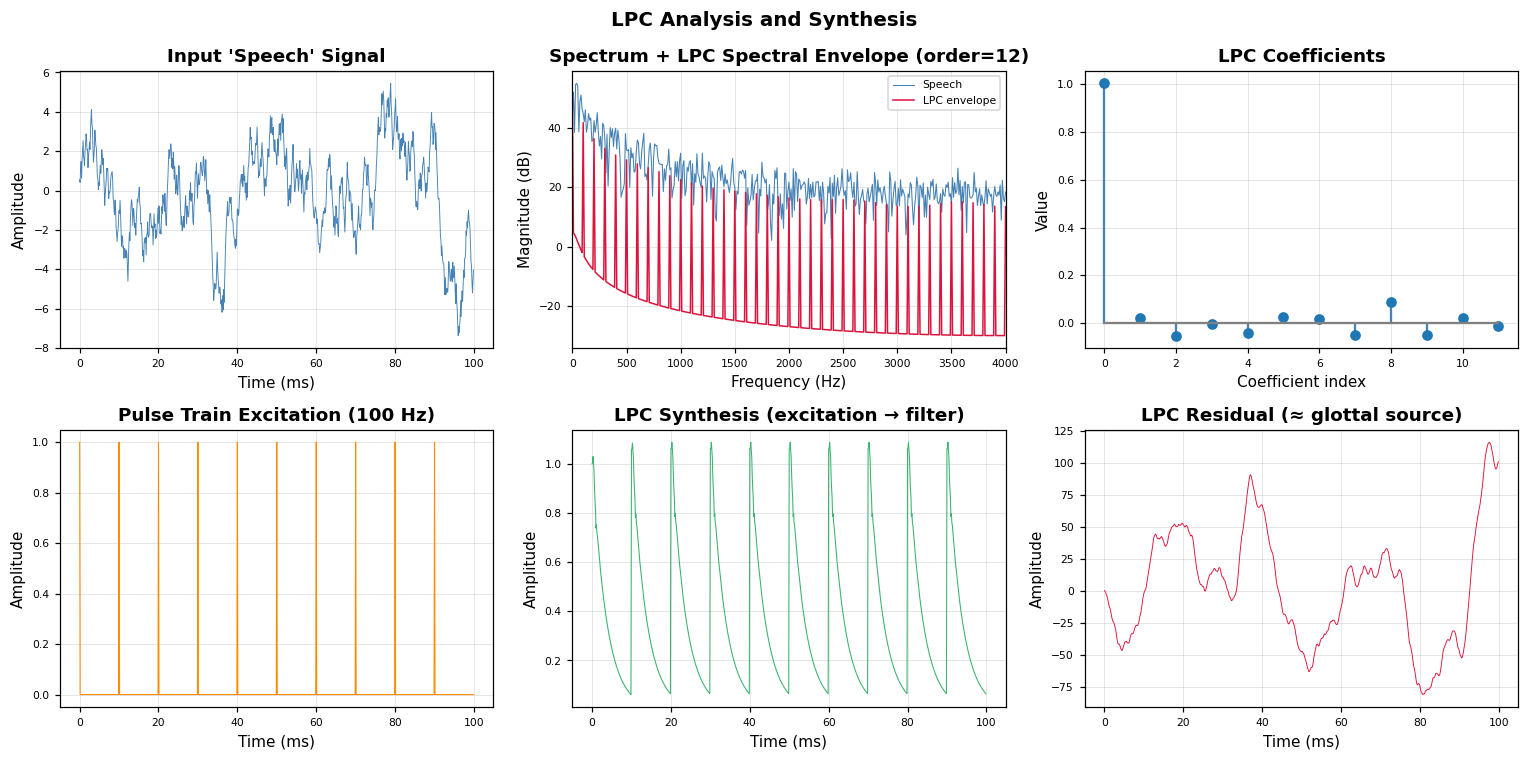

In [2]:
FS = 8000  # telephone bandwidth — LPC works well here
DURATION = 0.1
ORDER = 12

# Voiced excitation: impulse train at 100 Hz
_, exc = generate_impulse(fs=FS, duration=DURATION)
pulse_period = int(FS / 100)
excitation = np.zeros(int(FS * DURATION))
excitation[::pulse_period] = 1.0

# Build a simple vowel-like signal with some formants via known poles
# Use a white-noise-excited resonance as "speech" to analyse
_, noise = generate_white_noise(fs=FS, duration=DURATION, seed=42)
from scipy.signal import lfilter as _lfilter
vowel = _lfilter([1.0], [1.0, -0.97], noise)  # pre-emphasis inverse for demo

coeffs = lpc_coeffs(vowel, order=ORDER)
synthesised = lpc_synthesize(excitation, coeffs)
residual = vowel - _lfilter([1.0], np.concatenate([[1.0], -coeffs]), vowel)

t_ms = np.arange(int(FS * DURATION)) / FS * 1000
freqs = np.fft.rfftfreq(int(FS * DURATION), d=1.0 / FS)


def _db(s: np.ndarray) -> np.ndarray:
    return 20 * np.log10(np.abs(np.fft.rfft(s)) + 1e-12)


fig, axes = plt.subplots(2, 3, figsize=(14, 7))

axes[0, 0].plot(t_ms, vowel, linewidth=0.6, color="steelblue")
axes[0, 0].set_title("Input 'Speech' Signal", fontweight="bold")
axes[0, 0].set_xlabel("Time (ms)")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].plot(freqs, _db(vowel), linewidth=0.7, color="steelblue", label="Speech")
env = _db(lpc_synthesize(excitation, coeffs))
axes[0, 1].plot(freqs, env, linewidth=1.0, color="crimson", label="LPC envelope")
axes[0, 1].set_title(f"Spectrum + LPC Spectral Envelope (order={ORDER})", fontweight="bold")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("Magnitude (dB)")
axes[0, 1].set_xlim(0, FS / 2)
axes[0, 1].legend(fontsize=7)

axes[0, 2].stem(range(ORDER), coeffs, linefmt="steelblue", markerfmt="C0o", basefmt="gray")
axes[0, 2].set_title("LPC Coefficients", fontweight="bold")
axes[0, 2].set_xlabel("Coefficient index")
axes[0, 2].set_ylabel("Value")

axes[1, 0].plot(t_ms, excitation, linewidth=0.7, color="darkorange")
axes[1, 0].set_title("Pulse Train Excitation (100 Hz)", fontweight="bold")
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylabel("Amplitude")

n = min(len(t_ms), len(synthesised))
axes[1, 1].plot(t_ms[:n], synthesised[:n], linewidth=0.7, color="mediumseagreen")
axes[1, 1].set_title("LPC Synthesis (excitation → filter)", fontweight="bold")
axes[1, 1].set_xlabel("Time (ms)")
axes[1, 1].set_ylabel("Amplitude")

n_res = min(len(t_ms), len(residual))
axes[1, 2].plot(t_ms[:n_res], residual[:n_res], linewidth=0.6, color="crimson")
axes[1, 2].set_title("LPC Residual (≈ glottal source)", fontweight="bold")
axes[1, 2].set_xlabel("Time (ms)")
axes[1, 2].set_ylabel("Amplitude")

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("LPC Analysis and Synthesis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()